# Which Attention Heads Does T5 Actually Need?

**Gradient-based head importance and structured pruning on T5-small**

T5-small has 144 attention heads: 6 encoder layers and 6 decoder layers of 8 heads each,
plus 6 layers of 8 cross-attention heads joining them. They are not equally useful. This
notebook measures how much each one matters, removes the least important ones, and
watches what happens to translation quality.

The plan:

1. translate English→German with the unmodified model and score it with a **BLEU written
   from scratch**
2. score every head by **how much the loss moves when the head is switched off** — the
   gradient-based importance of Michel, Levy and Neubig (2019)
3. **prune** the lowest-scoring heads, 20% / 40% / 60% at a time, separately for
   encoder self-attention, decoder self-attention, and cross-attention
4. compare against **randomly chosen heads** at the same sparsity, which is the control
   that tells you whether the importance scores mean anything

Data is the Multi30k 2016 test set (1,000 English–German sentence pairs). The model is
downloaded from the Hugging Face hub by the notebook itself.

## 1. Setup

In [1]:
import gzip, io, math, random, time, urllib.request
from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import T5ForConditionalGeneration, T5TokenizerFast
from transformers.models.t5.modeling_t5 import T5Attention

torch.manual_seed(0)
random.seed(0)

BLUE, ORANGE, PLUM = "#007096", "#c2703a", "#8a3b6b"
INK, GREY = "#1b2528", "#5a6b70"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9.5, "figure.facecolor": "white",
    "axes.edgecolor": GREY, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": GREY, "ytick.color": GREY, "axes.titlesize": 10,
    "axes.titlelocation": "left", "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False, "lines.linewidth": 2,
})

tokenizer = T5TokenizerFast.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")
model.eval()

LAYERS, HEADS = model.config.num_layers, model.config.num_heads
print(f"t5-small: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")
print(f"{LAYERS} layers x {HEADS} heads, three attention types = {3*LAYERS*HEADS} heads total")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:  56%|█████▌    | 73/131 [00:00<00:00, 701.18it/s]

Loading weights: 100%|██████████| 131/131 [00:00<00:00, 976.13it/s]

t5-small: 60.5M parameters
6 layers x 8 heads, three attention types = 144 heads total


In [2]:
# Multi30k 2016 test set: 1,000 English-German sentence pairs
BASE = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/"

def fetch(name):
    with urllib.request.urlopen(BASE + name, timeout=60) as r:
        return gzip.decompress(r.read()).decode("utf-8").splitlines()

english = fetch("test_2016_flickr.en.gz")
german = fetch("test_2016_flickr.de.gz")
print(f"{len(english)} sentence pairs")
for e, g in zip(english[:3], german[:3]):
    print(f"  EN  {e}\n  DE  {g}\n")

1000 sentence pairs
  EN  A man in an orange hat starring at something.
  DE  Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.

  EN  A Boston Terrier is running on lush green grass in front of a white fence.
  DE  Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.

  EN  A girl in karate uniform breaking a stick with a front kick.
  DE  Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.



## 2. BLEU, written out

BLEU compares a candidate translation against a reference using n-gram precision, with
two corrections that matter:

**Clipping.** A candidate that repeats "the" ten times should not score ten matches for
one "the" in the reference. Each n-gram's count is clipped at how many times it appears
in the reference.

**Brevity penalty.** Precision alone rewards saying almost nothing, so output shorter
than the reference is multiplied by $e^{1-r/c}$.

$$\text{BLEU} = \text{BP} \cdot \exp\left(\frac{1}{N}\sum_{n=1}^{N}\log p_n\right)$$

This is corpus-level BLEU: counts are pooled across all sentences before the ratio is
taken, which is the standard and is not the same as averaging sentence BLEUs.

In [3]:
def ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def corpus_bleu(candidates, references, max_n=4):
    matched = [0] * max_n
    total = [0] * max_n
    cand_len = ref_len = 0

    for cand, ref in zip(candidates, references):
        c_tokens, r_tokens = cand.split(), ref.split()
        cand_len += len(c_tokens)
        ref_len += len(r_tokens)
        for n in range(1, max_n + 1):
            c_grams, r_grams = ngrams(c_tokens, n), ngrams(r_tokens, n)
            total[n - 1] += max(0, len(c_tokens) - n + 1)
            for g, count in c_grams.items():
                matched[n - 1] += min(count, r_grams[g])      # clipped

    if min(matched) == 0:
        return 0.0
    log_precision = sum(math.log(matched[i] / total[i]) for i in range(max_n)) / max_n
    penalty = 1.0 if cand_len > ref_len else math.exp(1 - ref_len / max(cand_len, 1))
    return penalty * math.exp(log_precision)


# a sanity check: identical text must score 1.0, and a truncated candidate must be
# punished by the brevity penalty even though its precision is perfect
assert abs(corpus_bleu(["a b c d e"], ["a b c d e"]) - 1.0) < 1e-9
print("identical  :", round(corpus_bleu(["a b c d e"], ["a b c d e"]), 4))
print("truncated  :", round(corpus_bleu(["a b c d"], ["a b c d e"]), 4), " (precision is perfect; BP does the work)")
print("repetitive :", round(corpus_bleu(["a a a a a"], ["a b c d e"]), 4), " (clipping does the work)")

identical  : 1.0
truncated  : 0.7788  (precision is perfect; BP does the work)
repetitive : 0.0  (clipping does the work)


## 3. Switching heads off

Recent versions of `transformers` no longer accept a `head_mask` argument through
`generate`, so the masking is done directly instead.

Every attention module concatenates its heads before the output projection `o`, so the
input to `o` is a vector of length `n_heads × d_kv`. Reshaping it to `(n_heads, d_kv)`
and multiplying by a per-head scalar switches individual heads off — and because the
multiply is an ordinary tensor operation, the mask is **differentiable**, which is what
makes the importance scores in the next section possible.

A forward pre-hook on `o` applies it, so this works unchanged during generation.

In [4]:
def head_group(name):
    """encoder self-attention, decoder self-attention, or cross-attention"""
    if name.startswith("encoder"):
        return "encoder self"
    return "decoder self" if ".layer.0." in name else "cross"


def layer_index(name):
    return int(name.split(".block.")[1].split(".")[0])


masks, handles = {}, []
for name, module in model.named_modules():
    if isinstance(module, T5Attention):
        mask = torch.ones(module.n_heads, requires_grad=True)
        masks[name] = mask

        def pre_hook(mod, args, mask=mask, nh=module.n_heads, dk=module.key_value_proj_dim):
            x = args[0]
            x = (x.view(*x.shape[:-1], nh, dk) * mask.view(nh, 1)).reshape(*x.shape[:-1], nh * dk)
            return (x,) + args[1:]

        handles.append(module.o.register_forward_pre_hook(pre_hook))

NAMES = sorted(masks, key=lambda n: (head_group(n), layer_index(n)))
GROUPS = ["encoder self", "decoder self", "cross"]

def set_mask(active):
    """active[name] is a 0/1 vector over that module's heads"""
    for name, mask in masks.items():
        mask.data = active[name].clone()

def all_on():
    return {name: torch.ones(HEADS) for name in masks}

print(f"{len(masks)} attention modules hooked")
for g in GROUPS:
    print(f"  {g:<14} {sum(1 for n in NAMES if head_group(n) == g)} layers x {HEADS} heads")

18 attention modules hooked
  encoder self   6 layers x 8 heads
  decoder self   6 layers x 8 heads
  cross          6 layers x 8 heads


## 4. Baseline translation quality

In [5]:
N_EVAL = 120                      # sentences scored per configuration
sources = english[:N_EVAL]
targets = german[:N_EVAL]
prompts = ["translate English to German: " + s for s in sources]


@torch.no_grad()
def translate(batch_size=12, max_new_tokens=48):
    outputs = []
    for i in range(0, len(prompts), batch_size):
        batch = tokenizer(prompts[i:i + batch_size], return_tensors="pt",
                          padding=True, truncation=True, max_length=96)
        generated = model.generate(**batch, max_new_tokens=max_new_tokens, num_beams=1)
        outputs += tokenizer.batch_decode(generated, skip_special_tokens=True)
    return outputs


set_mask(all_on())
started = time.time()
baseline_output = translate()
baseline_bleu = corpus_bleu(baseline_output, targets)
print(f"baseline BLEU {baseline_bleu:.4f}   ({time.time()-started:.0f}s for {N_EVAL} sentences)\n")
for src, hyp, ref in zip(sources[:3], baseline_output[:3], targets[:3]):
    print(f"  EN   {src}\n  T5   {hyp}\n  REF  {ref}\n")

baseline BLEU 0.2534   (14s for 120 sentences)

  EN   A man in an orange hat starring at something.
  T5   Ein Mann in einem orangen Hut, der auf etwas dreht.
  REF  Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.

  EN   A Boston Terrier is running on lush green grass in front of a white fence.
  T5   Ein Boston Terrier läuft auf üppigem grünen Gras vor einem weißen Zaun.
  REF  Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.

  EN   A girl in karate uniform breaking a stick with a front kick.
  T5   Ein Mädchen in Karate-Uniform, das einen Stick mit einem Front Kick bricht.
  REF  Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.



## 5. Scoring every head

The importance of head $h$ is how much the loss would change if that head were switched
off. Rather than removing 144 heads one at a time and re-running the model, take the
derivative of the loss with respect to the mask variable:

$$I_h = \left| \frac{\partial \mathcal{L}}{\partial \xi_h} \right|$$

where $\xi_h$ is the head's mask, sitting at 1. This is a first-order estimate of the
damage that setting $\xi_h = 0$ would do, and it costs **one forward and backward pass**
for all 144 heads instead of 144 separate evaluations.

The loss is ordinary teacher-forced cross-entropy against the German reference. Scores
are accumulated over several batches and averaged, because a single batch is noisy.

In [6]:
def head_importance(n_sentences=200, batch_size=8):
    scores = {name: torch.zeros(HEADS) for name in masks}
    set_mask(all_on())
    for m in masks.values():
        m.requires_grad_(True)

    batches = 0
    for i in range(0, n_sentences, batch_size):
        src = ["translate English to German: " + s for s in english[i:i + batch_size]]
        tgt = german[i:i + batch_size]
        encoded = tokenizer(src, return_tensors="pt", padding=True, truncation=True, max_length=96)
        labels = tokenizer(tgt, return_tensors="pt", padding=True, truncation=True,
                           max_length=96).input_ids
        labels[labels == tokenizer.pad_token_id] = -100

        model.zero_grad(set_to_none=True)
        for m in masks.values():
            m.grad = None
        loss = model(**encoded, labels=labels).loss
        loss.backward()

        for name, m in masks.items():
            if m.grad is not None:
                scores[name] += m.grad.abs().detach()
        batches += 1

    for name in scores:
        scores[name] /= batches
    return scores


started = time.time()
importance = head_importance()
print(f"scored {3*LAYERS*HEADS} heads in {time.time()-started:.0f}s\n")

for g in GROUPS:
    values = torch.cat([importance[n] for n in NAMES if head_group(n) == g])
    print(f"{g:<14} mean {values.mean():.5f}   max {values.max():.5f}   "
          f"min {values.min():.5f}   ratio max/min {values.max()/values.min():.0f}x")

scored 144 heads in 20s

encoder self   mean 0.00511   max 0.01035   min 0.00134   ratio max/min 8x
decoder self   mean 0.00460   max 0.01010   min 0.00228   ratio max/min 4x
cross          mean 0.00564   max 0.01078   min 0.00139   ratio max/min 8x


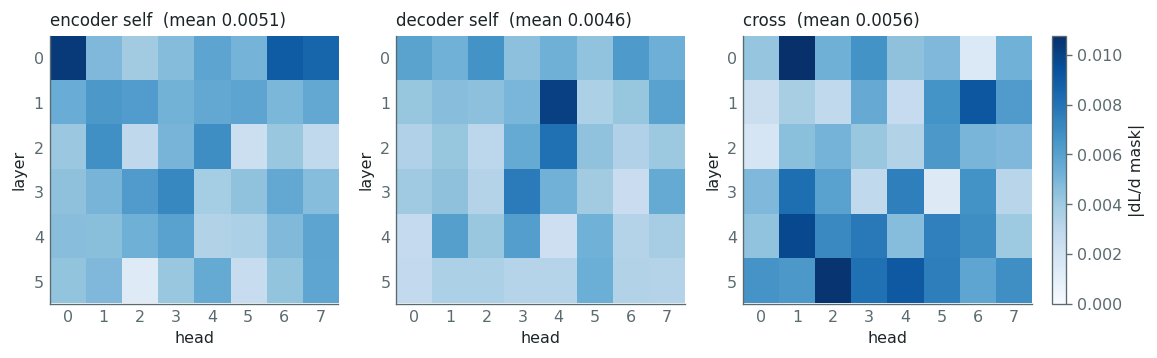

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
vmax = max(importance[n].max().item() for n in NAMES)

for ax, group in zip(axes, GROUPS):
    names = [n for n in NAMES if head_group(n) == group]
    names.sort(key=layer_index)
    grid = np.stack([importance[n].detach().numpy() for n in names])
    im = ax.imshow(grid, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xlabel("head"); ax.set_ylabel("layer")
    ax.set_xticks(range(HEADS)); ax.set_yticks(range(LAYERS))
    ax.set_title(f"{group}  (mean {grid.mean():.4f})")
    ax.tick_params(length=0)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="|dL/d mask|")
plt.show()

## 6. Pruning

Within each attention type, switch off the lowest-scoring fraction of heads and
re-translate. The control is the same number of heads chosen **at random** — if
importance-based pruning is no better than random, the scores are not measuring anything.

In [8]:
def prune(group, fraction, strategy="importance", seed=0):
    """Turn off `fraction` of the heads in one attention type."""
    active = all_on()
    names = [n for n in NAMES if head_group(n) == group]
    flat = [(name, h, importance[name][h].item()) for name in names for h in range(HEADS)]
    k = int(round(fraction * len(flat)))
    if strategy == "importance":
        flat.sort(key=lambda t: t[2])              # least important first
        doomed = flat[:k]
    else:
        doomed = random.Random(seed).sample(flat, k)
    for name, h, _ in doomed:
        active[name][h] = 0.0
    set_mask(active)
    return k


results = []
for group in GROUPS:
    for fraction in (0.2, 0.4, 0.6):
        for strategy in ("importance", "random"):
            k = prune(group, fraction, strategy)
            score = corpus_bleu(translate(), targets)
            results.append({"group": group, "fraction": fraction, "strategy": strategy,
                            "heads_removed": k, "bleu": score,
                            "retained": score / baseline_bleu})
            print(f"{group:<14} {int(fraction*100):>3}% {strategy:<11} "
                  f"({k:>2} heads)  BLEU {score:.4f}  = {score/baseline_bleu:6.1%} of baseline")
    set_mask(all_on())

encoder self    20% importance  (10 heads)  BLEU 0.2512  =  99.1% of baseline


encoder self    20% random      (10 heads)  BLEU 0.2580  = 101.8% of baseline


encoder self    40% importance  (19 heads)  BLEU 0.2528  =  99.8% of baseline


encoder self    40% random      (19 heads)  BLEU 0.2464  =  97.2% of baseline


encoder self    60% importance  (29 heads)  BLEU 0.2466  =  97.3% of baseline


...

cross           20% random      (10 heads)  BLEU 0.2602  = 102.7% of baseline


cross           40% importance  (19 heads)  BLEU 0.2508  =  99.0% of baseline


cross           40% random      (19 heads)  BLEU 0.1565  =  61.8% of baseline


cross           60% importance  (29 heads)  BLEU 0.2305  =  91.0% of baseline


cross           60% random      (29 heads)  BLEU 0.0323  =  12.8% of baseline


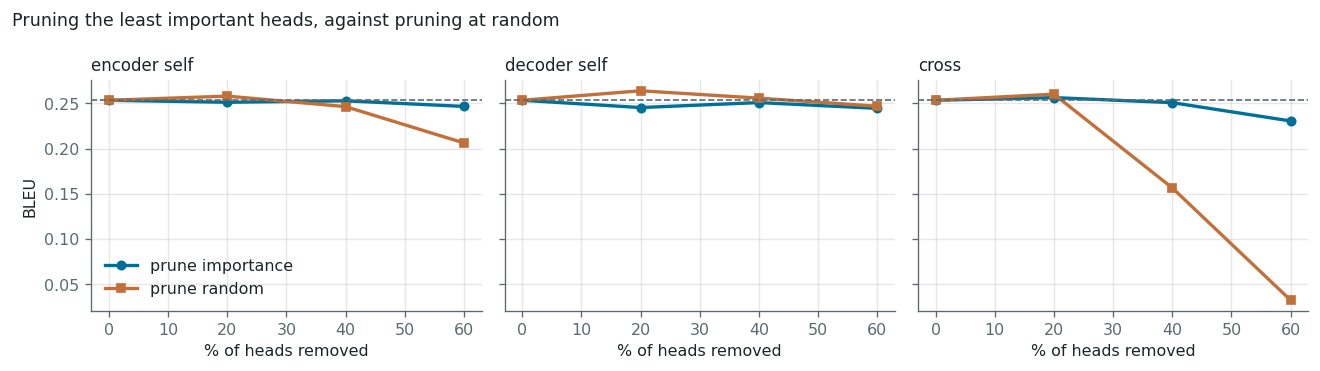

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), sharey=True)
for ax, group in zip(axes, GROUPS):
    for strategy, colour, marker in [("importance", BLUE, "o"), ("random", ORANGE, "s")]:
        rows = [r for r in results if r["group"] == group and r["strategy"] == strategy]
        x = [0] + [r["fraction"] * 100 for r in rows]
        y = [baseline_bleu] + [r["bleu"] for r in rows]
        ax.plot(x, y, color=colour, marker=marker, ms=5, label=f"prune {strategy}")
    ax.axhline(baseline_bleu, color=GREY, ls="--", lw=1)
    ax.set_xlabel("% of heads removed")
    ax.set_title(group)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("BLEU")
axes[0].legend()
fig.suptitle("Pruning the least important heads, against pruning at random",
             x=0.005, ha="left", fontsize=10.5)
plt.tight_layout(); plt.show()

## 7. The extreme case

Removing an entire attention type shows what each one is for. Cross-attention is the only
path from the encoder to the decoder — without it the decoder cannot see the English
sentence at all, and can only produce German-shaped noise.

In [10]:
for group in GROUPS:
    prune(group, 1.0)
    output = translate(batch_size=12)
    print(f"--- {group} removed entirely -> BLEU {corpus_bleu(output, targets):.4f}")
    print(f"    {output[0][:90]}")
    set_mask(all_on())

print(f"\n--- nothing removed        -> BLEU {baseline_bleu:.4f}")
print(f"    {baseline_output[0][:90]}")

--- encoder self removed entirely -> BLEU 0.0000
    a.


--- decoder self removed entirely -> BLEU 0.0256
    Ein Mann in einem Mann in einem Mann in einem Mann in einem Mann in einem Mann in einem Ma


--- cross removed entirely -> BLEU 0.0000
    a,,,,,,,,,,,,,, a,,, and to the a

--- nothing removed        -> BLEU 0.2534
    Ein Mann in einem orangen Hut, der auf etwas dreht.


## 8. Summary

In [11]:
print(f"baseline BLEU on {N_EVAL} Multi30k sentences: {baseline_bleu:.4f}\n")
print(f"{'attention type':<15}{'removed':>9}{'importance':>13}{'random':>10}{'gap':>8}")
print("-" * 56)
for group in GROUPS:
    for fraction in (0.2, 0.4, 0.6):
        imp = next(r for r in results if r["group"] == group and r["fraction"] == fraction
                   and r["strategy"] == "importance")
        rnd = next(r for r in results if r["group"] == group and r["fraction"] == fraction
                   and r["strategy"] == "random")
        print(f"{group:<15}{int(fraction*100):>7}% {imp['bleu']:>12.4f}{rnd['bleu']:>10.4f}"
              f"{imp['bleu']-rnd['bleu']:>+8.4f}")
print("-" * 56)

def gap(group, fraction):
    imp = next(r for r in results if r["group"] == group and r["fraction"] == fraction
               and r["strategy"] == "importance")["bleu"]
    rnd = next(r for r in results if r["group"] == group and r["fraction"] == fraction
               and r["strategy"] == "random")["bleu"]
    return imp - rnd

print("\nmean advantage of importance over random, by how much is removed:")
for fraction in (0.2, 0.4, 0.6):
    mean_gap = sum(gap(g, fraction) for g in GROUPS) / len(GROUPS)
    print(f"  {int(fraction*100):>3}% removed : {mean_gap:+.4f} BLEU")

print("\nRead the 20% row with care. Removing a tenth of one attention type barely moves\n"
      f"BLEU either way, and on {N_EVAL} sentences the differences there are inside the\n"
      "noise - random selection can and does come out ahead. The scores only prove their\n"
      "worth once enough is removed that the choice matters.")

worst = max(GROUPS, key=lambda g: gap(g, 0.6))
imp60 = next(r for r in results if r["group"] == worst and r["fraction"] == 0.6
             and r["strategy"] == "importance")
rnd60 = next(r for r in results if r["group"] == worst and r["fraction"] == 0.6
             and r["strategy"] == "random")
print(f"\nThe clearest case is {worst} at 60%: choosing by importance keeps "
      f"{imp60['retained']:.0%} of baseline BLEU,\nwhile choosing at random keeps "
      f"{rnd60['retained']:.0%}. Same number of heads removed, {imp60['bleu']-rnd60['bleu']:+.4f} BLEU apart.")

survivable = [r for r in results if r["strategy"] == "importance" and r["retained"] > 0.9]
if survivable:
    best = max(survivable, key=lambda r: r["heads_removed"])
    print(f"\nLargest cut still keeping >90% of BLEU: {best['heads_removed']} "
          f"{best['group']} heads ({int(best['fraction']*100)}%), BLEU {best['bleu']:.4f}")

baseline BLEU on 120 Multi30k sentences: 0.2534

attention type   removed   importance    random     gap
--------------------------------------------------------
encoder self        20%       0.2512    0.2580 -0.0068
encoder self        40%       0.2528    0.2464 +0.0064
encoder self        60%       0.2466    0.2062 +0.0404
decoder self        20%       0.2454    0.2639 -0.0186
decoder self        40%       0.2509    0.2558 -0.0049
decoder self        60%       0.2445    0.2469 -0.0024
cross               20%       0.2564    0.2602 -0.0038
cross               40%       0.2508    0.1565 +0.0943
cross               60%       0.2305    0.0323 +0.1982
--------------------------------------------------------

mean advantage of importance over random, by how much is removed:
   20% removed : -0.0097 BLEU
   40% removed : +0.0319 BLEU
   60% removed : +0.0787 BLEU

Read the 20% row with care. Removing a tenth of one attention type barely moves
BLEU either way, and on 120 sentences the differ

## Things worth being able to explain

1. Why the gradient of the loss with respect to a mask estimates the damage of removing that head, and where that first-order approximation breaks down.
2. Why this costs one backward pass instead of 144 forward passes.
3. What cross-attention does that self-attention cannot, and why removing it is catastrophic while removing encoder self-attention is survivable.
4. The difference between masking a head and actually deleting it — masking measures the effect, deleting is what makes the model smaller and faster.
5. Why random pruning is the control that makes the importance scores meaningful.
6. What BLEU's clipping and brevity penalty each prevent.
7. Why corpus-level BLEU is not the average of sentence-level BLEUs.